# **Feature Analysis**

*Analyzing important features of the raw datasets*

---

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET = 'car_details'
DATASET2 = 'car_details_155998_20250907'


df = pd.read_csv(f'../data/raw/{DATASET2}.csv')
#df = pd.read_csv(f'../data/clean/{DATASET2}.csv')


## **Missing Values**

---

In [30]:
total_cars = []

total_cars_df = pd.DataFrame({
    'Total Cars' : [len(df)]
})
display(total_cars_df.style.hide(axis='index'))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~
missing_data = []

features = ['price', 'manufacturer', 'model', 'year', 'kilometers', 'fuel_type', 'kw', 'le', 'condition',
    'trunk_capacity', 'body_type', 'seats', 'color', 'engine_capacity', 'drive_type', 'transmission_type', 
    'number_of_gears', 'transmission_subtype'
]

for col in features:
    missing_count = df[col].isna().sum()
    missing_data.append({
        'Feature': col.replace('_', ' ').title(),
        'Missing Count': missing_count,
        'Missing %': f'{(missing_count/len(df))*100:.2f}%'
    })

missing_df = pd.DataFrame(missing_data)
display(missing_df.style.hide(axis='index'))

Total Cars
155998


Feature,Missing Count,Missing %
Price,1024,0.66%
Manufacturer,0,0.00%
Model,13,0.01%
Year,0,0.00%
Kilometers,2145,1.38%
Fuel Type,2123,1.36%
Kw,2673,1.71%
Le,2673,1.71%
Condition,0,0.00%
Trunk Capacity,20750,13.30%


## **Price Analysis**

---

### **Price Ranges**


Range,Count,%
0 - 100k,113,0.07
100k - 200k,752,0.48
200k - 300k,1705,1.09
300k - 500k,5223,3.35
500k - 1M,13236,8.48
1M - 2M,25329,16.24
2M - 3M,20416,13.09
3M - 5M,27008,17.31
5M - 10M,31187,19.99
10M - 20M,21018,13.47


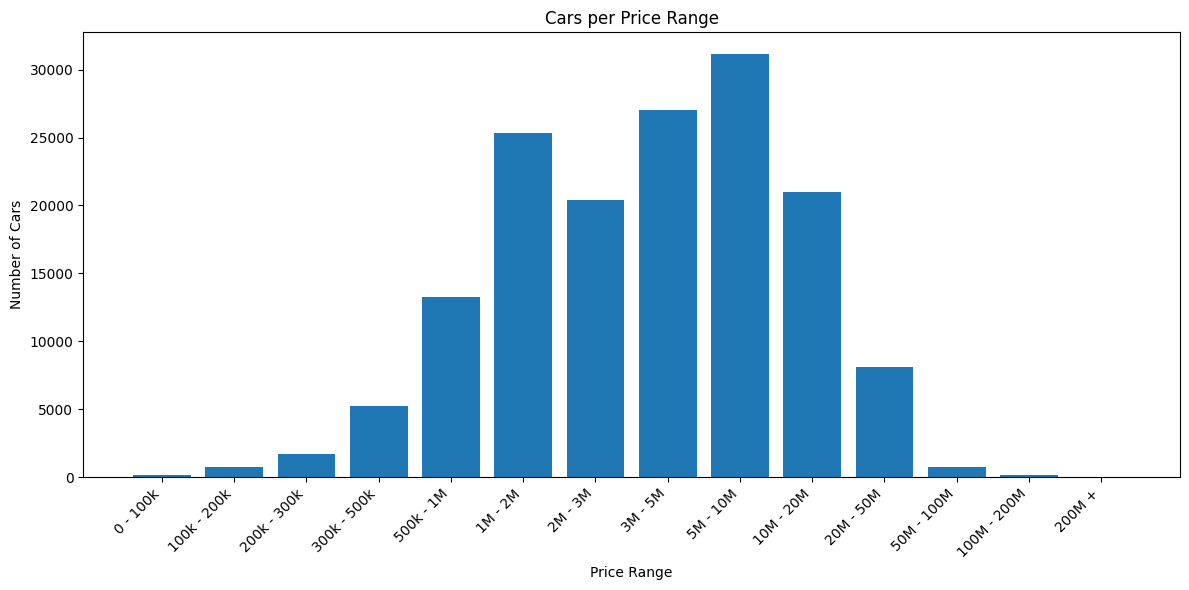

In [31]:
ranges = [
    (0, 100_000, "0 - 100k"),
    (100_000, 200_000, "100k - 200k"),
    (200_000, 300_000, "200k - 300k"),
    (300_000, 500_000, "300k - 500k"),
    (500_000, 1_000_000, "500k - 1M"),
    (1_000_000, 2_000_000, "1M - 2M"),
    (2_000_000, 3_000_000, "2M - 3M"),
    (3_000_000, 5_000_000, "3M - 5M"),
    (5_000_000, 10_000_000, "5M - 10M"),
    (10_000_000, 20_000_000, "10M - 20M"),
    (20_000_000, 50_000_000, "20M - 50M"),
    (50_000_000, 100_000_000, "50M - 100M"),
    (100_000_000, 200_000_000, "100M - 200M"),
    (200_000_000, float('inf'), "200M +")
]

data = []
for low, high, label in ranges:
    count = len(df[(df['price'] >= low) & (df['price'] < high)])
    percent = count / len(df) * 100
    data.append({
        'Range': label,
        'Count': count,
        '%': f'{percent:.2f}'
    })

price_ranges_df = pd.DataFrame(data)
display(price_ranges_df.style.hide(axis='index'))



plt.figure(figsize=(12,6))
plt.bar(price_ranges_df['Range'], price_ranges_df['Count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Price Range")
plt.ylabel("Number of Cars")
plt.title("Cars per Price Range")
plt.tight_layout()
plt.show()

### **Outliers by Price & Most Expensive, Cheapest Car Exploration**


In [32]:
cars_under_200k_df = df[df['price'] <= 200_000].sort_values('price').head(30)
cars_over_100M_df = df[df['price'] >= 100_000_000].sort_values('price', ascending=False).head(30)

cars_under_200k_df = pd.DataFrame({
    'Price' : cars_under_200k_df['price'].values.astype(int),
    'Manufacturer' : cars_under_200k_df['manufacturer'].values,
    'Model' : cars_under_200k_df['model'].values,
    'Year' : cars_under_200k_df['year'].values,
    'kw' : cars_under_200k_df['kw'].values,

    '' : ' | ',
})

cars_over_100M_df = pd.DataFrame({
    '' : ' | ',
    'Price' : cars_over_100M_df['price'].values.astype(int),
    'Manufacturer' : cars_over_100M_df['manufacturer'].values,
    'Model' : cars_over_100M_df['model'].values,
    'Year' : cars_over_100M_df['year'].values,
    'kw' : cars_over_100M_df['kw'].values
})



combined = pd.concat(
    [cars_under_200k_df, cars_over_100M_df],
    axis=1
)
combined['Price'] = combined['Price'].map(lambda x: f"{int(x):,}".replace(",", " "))
for col in ["Year", "kw"]:
    combined[col] = combined[col].map(lambda x: f"{x:.2f}") 


pd.set_option("display.max_rows", None)
display(combined.style.hide(axis="index"))


Price,Manufacturer,Model,Year,kw,,,Price,Manufacturer,Model,Year,kw
1,HYUNDAI,IONIQ 5,2022.92,168.00,|,|,1 230 191 104,MCLAREN,P1,2016.25,735.00
1,OPEL,OMEGA OMEGA B,1995.00,125.00,|,|,359 999 999,MERCEDES-MAYBACH,EGYÉB,2021.42,463.00
1,PEUGEOT,305,1984.00,57.00,|,|,355 775 000,MERCEDES-AMG,G-OSZTÁLY G 63,2015.83,400.00
3,OPEL,VIVARO,2010.92,66.00,|,|,330 200 000,FERRARI,SF90 SPIDER,2022.58,574.00
9,LADA,1500,1995.00,55.00,|,|,268 500 000,LAMBORGHINI,REVUELTO,2024.00,747.00
47,VOLKSWAGEN,TOUAREG,2012.00,180.00,|,|,252 000 000,FERRARI,SF90 SPIDER,2024.75,574.00
100,RENAULT,MEGANE,1996.42,108.00,|,|,249 900 000,FERRARI,SF90 SPIDER,2023.33,736.00
490,HONDA,CIVIC,1994.33,55.00,|,|,246 500 000,FERRARI,SF90 SPIDER,2025.00,nan
1 000,AUDI,A4,2019.33,140.00,|,|,234 300 000,MERCEDES-BENZ,G-OSZTÁLY G 63 AMG,2025.00,588.00
3 399,AUDI,A4,2010.50,88.00,|,|,234 300 000,MERCEDES-AMG,G-OSZTÁLY G 63,2025.00,588.00


### **Price Visualization with Log Transform**

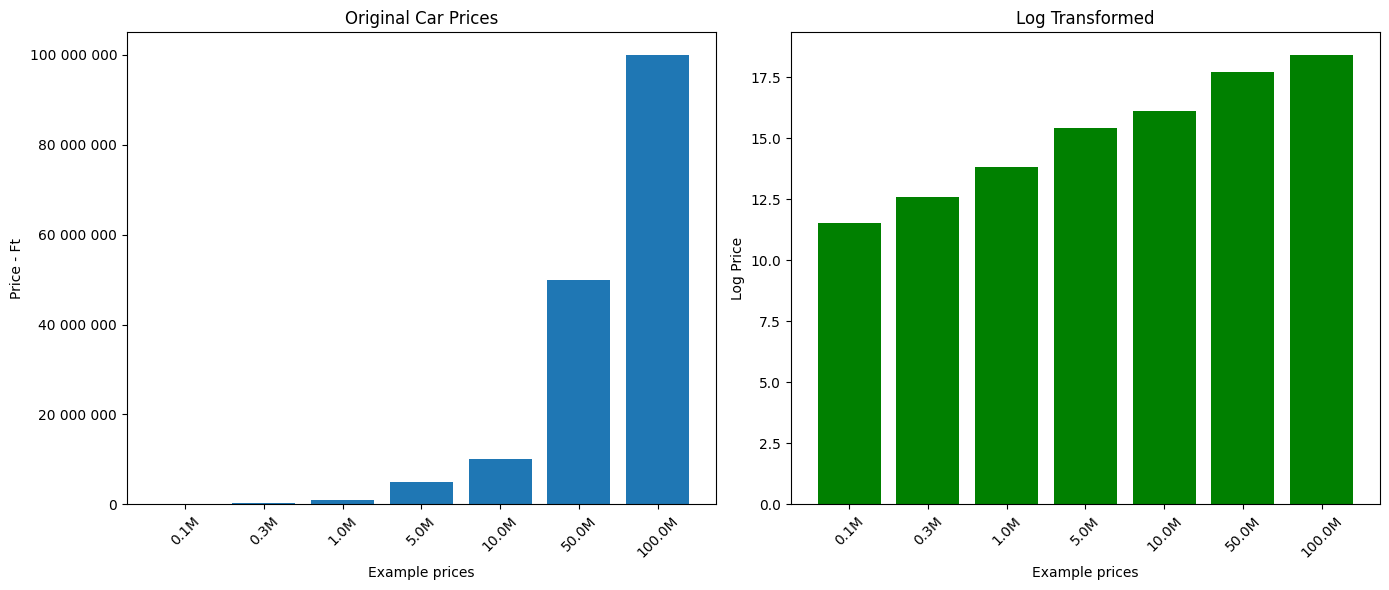

In [33]:
sample_prices = [100_000, 300_000, 1_000_000, 5_000_000, 10_000_000, 50_000_000, 100_000_000]
log_prices = np.log(sample_prices)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.set_title('Original Car Prices')
ax1.set_xlabel('Example prices')
ax1.set_ylabel('Price - Ft')
ax1.bar(range(len(sample_prices)), sample_prices)
ax1.set_xticks(range(len(sample_prices)))
ax1.set_xticklabels([f"{p/1_000_000:.1f}M" for p in sample_prices], rotation=45)
ax1.yaxis.set_major_formatter(lambda x, _: f"{int(x):,}".replace(",", " "))

# Log transformed
ax2.set_title('Log Transformed')
ax2.set_xlabel('Example prices')
ax2.set_ylabel('Log Price')
ax2.bar(range(len(log_prices)), log_prices, color='green')
ax2.set_xticks(range(len(log_prices)))
ax2.set_xticklabels([f"{p/1_000_000:.1f}M" for p in sample_prices], rotation=45)


plt.tight_layout()
plt.show()

## **Manufacturer & Model Analysis**

---

### **Unique Manufacturers & Their average prices**

In [34]:
manufacturer_unique_count = df['manufacturer'].nunique()
model_unique_count = df['model'].nunique()

manufacturer_unique_count_df = pd.DataFrame({
    'Unique Manufacturers' : [manufacturer_unique_count],
    'Unique Models' : [model_unique_count]
})
display(manufacturer_unique_count_df.style.hide(axis='index'))




manufacturer_unique_values = df['manufacturer'].value_counts()
manufacturer_avg_price = df.groupby('manufacturer')['price'].mean()
manufacturer_unique_models = df.groupby('manufacturer')['model'].nunique()

manufacturer_unique_df = pd.DataFrame({
    'Manufacturer': manufacturer_unique_values.index,
    'Car Count': manufacturer_unique_values.values,
    '%': (manufacturer_unique_values.values / len(df) * 100).round(2),
    'Unique Models': manufacturer_unique_models[manufacturer_unique_values.index].values,
    'Avg Price (M Ft)': (manufacturer_avg_price[manufacturer_unique_values.index] / 1e6).round(2)
})

pd.set_option("display.max_rows", None)
display(manufacturer_unique_df)

Unique Manufacturers,Unique Models
161,1797


,Manufacturer,Car Count,%,Unique Models,Avg Price (M Ft)
manufacturer,,,,,
VOLKSWAGEN,VOLKSWAGEN,14419,9.24,93,4.97
FORD,FORD,12560,8.05,53,5.33
OPEL,OPEL,12190,7.81,75,3.04
BMW,BMW,11525,7.39,114,10.16
MERCEDES-BENZ,MERCEDES-BENZ,10686,6.85,283,12.21
AUDI,AUDI,8806,5.64,48,8.80
TOYOTA,TOYOTA,7222,4.63,46,5.98
SKODA,SKODA,7199,4.61,24,5.24
RENAULT,RENAULT,5970,3.83,47,3.61


### **Manufacturer Removal Threshholds**



Threshold,Manufacturers Removed,Manufacturers Kept,Cars Removed,Cars Kept,Data Lost %
0,0,161,0,155998,0.00%
5,56,105,88,155910,0.06%
10,72,89,184,155814,0.12%
15,79,82,267,155731,0.17%
20,87,74,402,155596,0.26%
25,93,68,536,155462,0.34%
30,94,67,565,155433,0.36%


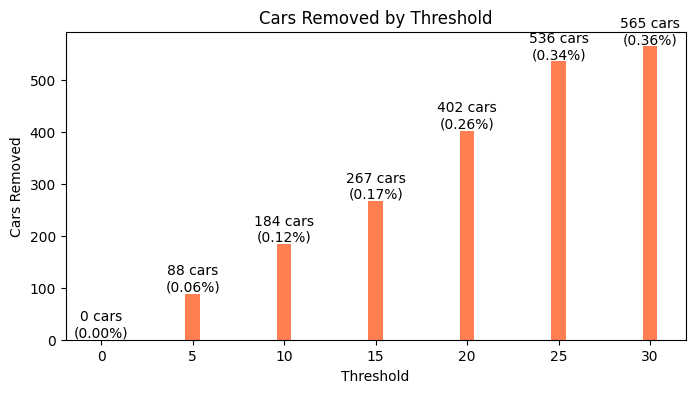

In [35]:
manufacturer_counts = df['manufacturer'].value_counts()
threshold_data = []

for threshold in [0,5, 10, 15, 20, 25, 30]:
    mask = manufacturer_counts < threshold
    
    threshold_data.append({
        'Threshold': threshold,
        'Manufacturers Removed': mask.sum(),
        'Manufacturers Kept': (~mask).sum(),
        'Cars Removed': manufacturer_counts[mask].sum(),
        'Cars Kept': manufacturer_counts[~mask].sum(),
        'Data Lost %': f'{(manufacturer_counts[mask].sum()/len(df)*100):.2f}%'
    })

threshold_df = pd.DataFrame(threshold_data)
display(threshold_df.style.hide(axis='index'))



fig, ax = plt.subplots(figsize=(8,4))
ax.bar(threshold_df['Threshold'], threshold_df['Cars Removed'], color='coral')
ax.set_xlabel('Threshold')
ax.set_ylabel('Cars Removed')
ax.set_title('Cars Removed by Threshold')

# %
for i in range(len(threshold_df)):
    ax.text(threshold_df['Threshold'][i], 
            threshold_df['Cars Removed'][i], 
            f'{threshold_df["Cars Removed"][i]} cars\n({threshold_df["Data Lost %"][i]})',  
            ha='center', va='bottom')
plt.show()

## **Year Analysis**

---

### **Year Ranges**

Range,Count,%,Avg Price (M Ft)
- 1990,1671,1.07,4.84
1990 - 2000,4777,3.06,1.69
2000 - 2005,12762,8.18,1.09
2005 - 2010,28750,18.43,1.79
2010 - 2015,33745,21.63,3.25
2015 - 2020,32256,20.68,6.70
2020 - 2025,28910,18.53,13.84
2025 -,13127,8.41,18.29


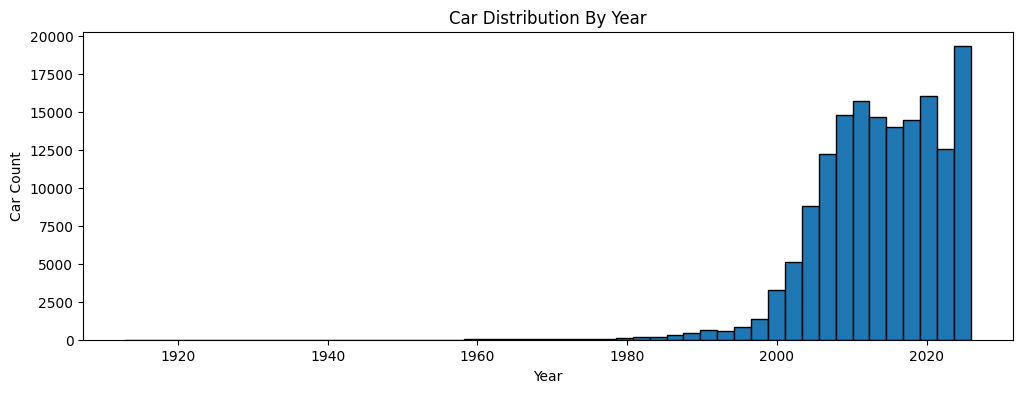

In [36]:
ranges = [
    (0, 1990, ' - 1990'),
    (1990, 2000, '1990 - 2000'),
    (2000, 2005, '2000 - 2005'),
    (2005, 2010, '2005 - 2010'),
    (2010, 2015, '2010 - 2015'),
    (2015, 2020, '2015 - 2020'),
    (2020, 2025, '2020 - 2025'),
    (2025, float('inf'), '2025 - ')
]

data = []
for low, high, label in ranges:
    mask = (df['year'] >= low) & (df['year'] < high)
    count = len(df[(df['year'] >= low) & (df['year'] < high)])
    percent = count / len(df) * 100
    avg_price = df[mask]['price'].mean()
    
    data.append({
        'Range': label,
        'Count': count,
        '%': f'{percent:.2f}',
        'Avg Price (M Ft)': f'{avg_price/1e6:.2f}'
    })

year_ranges_df = pd.DataFrame(data)
display(year_ranges_df.style.hide(axis='index'))


plt.figure(figsize=(12, 4))
plt.hist(df['year'].dropna(), bins=50, edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Car Count')
plt.title('Car Distribution By Year')
plt.show()


### **Outliers & Oldest, Newest Cars**

In [37]:
oldest_df = df.sort_values('year', ascending=True).head(20)
newest_df = df.sort_values('year', ascending=False).head(20)

oldest_df = pd.DataFrame({
    'Year': oldest_df['year'].values,
    'Price': oldest_df['price'].fillna(0).astype(int).values,
    'Manufacturer': oldest_df['manufacturer'].values,
    'Model': oldest_df['model'].values,
    
    '' : ' | '
})

newest_df = pd.DataFrame({
    '' : ' | ',

    'Year': newest_df['year'].values,
    'Price': newest_df['price'].values.astype(int),
    'Manufacturer': newest_df['manufacturer'].values,
    'Model': newest_df['model'].values
})

# Combine side by side
combined = pd.concat(
    [oldest_df, newest_df],
    axis=1
)
combined['Price'] = combined['Price'].map(lambda x: f"{int(x):,}".replace(",", " "))
for col in ["Year"]:
    combined[col] = combined[col].map(lambda x: f"{x:.2f}") 

# Display without index
pd.set_option("display.max_rows", None)
display(combined.style.hide(axis="index"))


Year,Price,Manufacturer,Model,,,Year,Price,Manufacturer,Model
1913.00,52 000 000,REPLIKA,EGYÉB,|,|,2025.92,13 849 000,MG,HS
1920.17,6 499 999,FIAT,508,|,|,2025.92,28 751 960,MERCEDES-BENZ,C-OSZTÁLY C 220
1925.00,10 000 000,PEUGEOT,172R,|,|,2025.92,22 571 450,MERCEDES-BENZ,GLA-OSZTÁLY GLA 180
1928.42,10 500 000,FORD,A MODELL,|,|,2025.92,31 940 000,MERCEDES-BENZ,GLC-OSZTÁLY
1929.00,8 500 000,CHRYSLER,EGYÉB,|,|,2025.92,22 352 710,MERCEDES-BENZ,CLA-OSZTÁLY CLA 250
1929.25,0,FORD,A MODELL,|,|,2025.92,37 468 000,MERCEDES-BENZ,GLE-OSZTÁLY
1929.42,0,ROLLS-ROYCE,PHANTOM,|,|,2025.92,33 606 200,MERCEDES-BENZ,GLC-OSZTÁLY GLC 220
1931.00,5 100 000,PEUGEOT,201,|,|,2025.92,42 917 840,MERCEDES-AMG,CLE CLE 53 4MATIC
1935.00,32 000 000,ADLER,JUNIOR,|,|,2025.92,13 849 000,MG,HS
1937.00,7 499 999,FIAT,508,|,|,2025.92,24 320 000,MERCEDES-BENZ,C-OSZTÁLY C 220


## **Kilometer Analysis**

---

### **Kilometer Ranges**



Range,Count,%,Avg Price
0 - 500,11924,7.64,17.10 M
500 - 50 000,15770,10.11,16.48 M
50 000 - 100 000,18796,12.05,8.61 M
100 000 - 200 000,53374,34.21,4.48 M
200 000 - 300 000,38083,24.41,2.80 M
300 000 - 500 000,15129,9.70,2.04 M
500 000 - 1 000 000,702,0.45,1.82 M
1 000 000 -,75,0.05,3.13 M


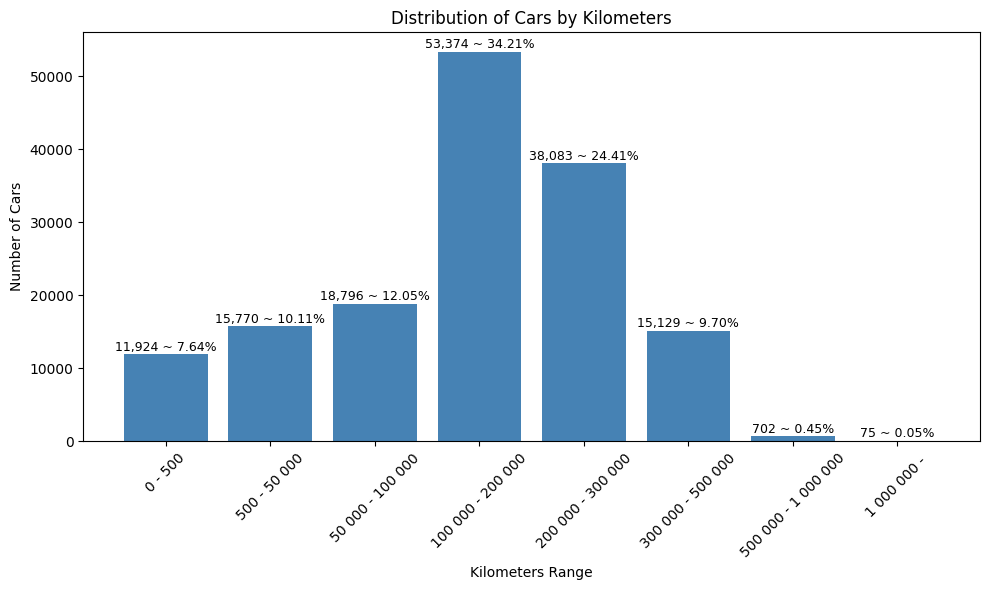

In [38]:
price_ranges = [
    (0, 500, '0 - 500'),
    (500, 50_000, '500 - 50 000'),
    (50_000, 100_000, '50 000 - 100 000'),
    (100_000, 200_000, '100 000 - 200 000'),
    (200_000, 300_000, '200 000 - 300 000'),
    (300_000, 500_000, '300 000 - 500 000'),
    (500_000, 1_000_000, '500 000 - 1 000 000'),
    (1_000_000, float('inf'), '1 000 000 - ')
]

data = []
for low, high, label in price_ranges:
    mask = (df['kilometers'] >= low) & (df['kilometers'] < high)
    count = len(df[(df['kilometers'] >= low) & (df['kilometers'] < high)])
    percent = count / len(df) * 100

    subset = df[mask]
    avg_price = subset['price'].mean()

    data.append({
        'Range': label,
        'Count': count,
        '%': f'{percent:.2f}',
        'Avg Price': f'{avg_price/1e6:.2f} M'
    })

km_ranges_df = pd.DataFrame(data)
display(km_ranges_df.style.hide(axis='index'))


# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(km_ranges_df['Range'], km_ranges_df['Count'], color='steelblue')
ax.set_xlabel('Kilometers Range')
ax.set_ylabel('Number of Cars')
ax.set_title('Distribution of Cars by Kilometers')
ax.tick_params(axis='x', rotation=45)

for bar, count, percent in zip(bars, km_ranges_df['Count'], km_ranges_df['%']):
   ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
           f'{count:,} ~ {percent}%',
           ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### **Outliers & Possible Errors, Cars with the most Kilometers**




In [39]:
top_km_df = df.sort_values('kilometers', ascending=False).head(50)

top_km_df = pd.DataFrame({
    'Kilometers': top_km_df['kilometers'].values,
    'Price': top_km_df['price'].fillna(0).astype(int).values,
    'Year' : top_km_df['year'].values,
    'Manufacturer': top_km_df['manufacturer'].values,
    'Model': top_km_df['model'].values,
    'Kw' : top_km_df['kw']
})

for col in ["Kilometers", "Price"]:
    top_km_df[col] = top_km_df[col].map(lambda x: f"{int(x):,}".replace(",", " "))
for col in ["Year", "Kw"]:
    top_km_df[col] = top_km_df[col].map(lambda x: f"{x:.2f}") 


display(top_km_df.style.hide(axis="index"))

Kilometers,Price,Year,Manufacturer,Model,Kw
16 777 215,300 000,2001.92,OPEL,CORSA CORSA C,55.00
16 777 215,10 480 000,2021.33,TESLA,MODEL 3,389.00
16 777 215,1 500 000,1984.00,VOLKSWAGEN,TRANSPORTER TRANSPORTER T3,44.00
16 777 215,2 599 000,2006.00,HONDA,CR-V,103.00
16 777 215,1 250 000,2013.00,SEAT,LEON,132.00
12 121 212,850 000,2003.00,HONDA,HR-V,77.00
8 457 201,865 000,1987.50,SUZUKI,SJ SAMURAI,nan
5 230 000,100 000,2005.00,HYUNDAI,MATRIX,nan
5 100 000,21 990 000,2024.00,AUDI,Q4,210.00
5 000 700,660 000,2000.58,VOLKSWAGEN,PASSAT PASSAT V,85.00


## **Fuel Type Analysis**

---

### **Overview of Unique Fuel Types**

Fuel Type,Avg Price,Count
Hibrid (Dízel),17 426 751,391
Hibrid (Benzin),15 722 725,3568
Elektromos,13 379 749,9179
Hibrid,11 783 495,3435
Benzin,5 854 718,77349
Dízel/Gáz,5 772 642,14
Dízel,5 735 264,58269
LPG,2 968 927,231
CNG,2 089 831,83
Etanol,1 962 291,34


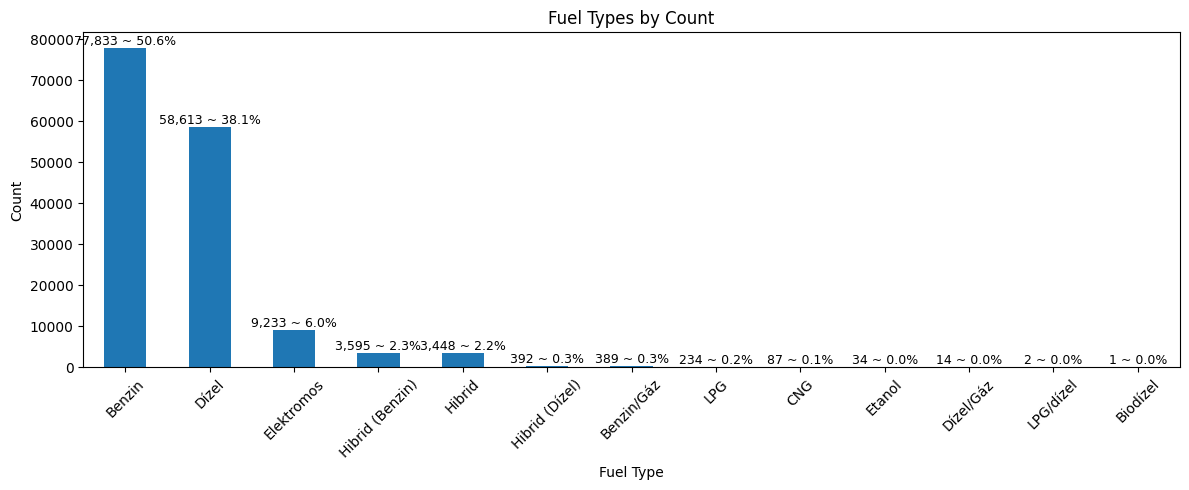

In [40]:
price_grouped = df.groupby('fuel_type')['price']
price_by_fuel = price_grouped.agg(['mean','count']).sort_values('mean', ascending=False).reset_index()
price_by_fuel = price_by_fuel.rename(columns={
    'fuel_type': 'Fuel Type',
    'mean': 'Avg Price',
    'count': 'Count'
})
price_by_fuel['Avg Price'] = price_by_fuel['Avg Price'].map(lambda x: f"{int(x):,}".replace(",", " "))
display(price_by_fuel.style.hide(axis='index'))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~

fuel_counts = df['fuel_type'].value_counts()
fig, ax = plt.subplots(figsize=(12, 5))

bars = fuel_counts.plot(kind='bar', ax=ax)
ax.set_title('Fuel Types by Count')
ax.set_xlabel('Fuel Type')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


total = fuel_counts.sum()
for bar, count in zip(ax.patches, fuel_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count:,} ~ {count/total:.1%}',
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()

## **Kw / LE Analysis**

---

### **Kw Ranges**

Range,Count,%,Avg Price - M
0 - 50,5356,3.43,1.190000
50 - 75,32999,21.15,2.500000
75 - 100,38843,24.90,3.820000
100 - 125,33528,21.49,6.340000
125 - 150,16303,10.45,8.540000
150 - 200,12103,7.76,10.410000
200 - 300,9547,6.12,17.440000
300 - 500,4444,2.85,30.380000
500 +,202,0.13,82.320000


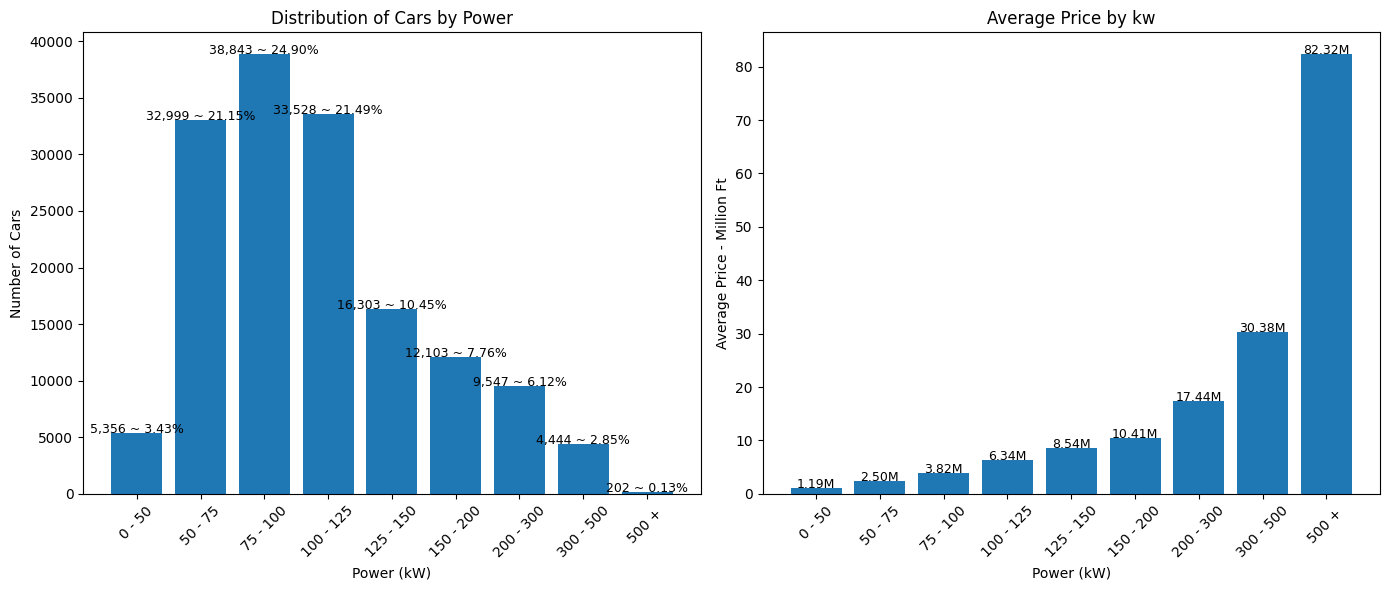

In [41]:
kw_ranges = [
   (0, 50, '0 - 50'),
   (50, 75, '50 - 75'),
   (75, 100, '75 - 100'),
   (100, 125, '100 - 125'),
   (125, 150, '125 - 150'),
   (150, 200, '150 - 200'),
   (200, 300, '200 - 300'),
   (300, 500, '300 - 500'),
   (500, float('inf'), '500 + ')
]

data = []
for low, high, label in kw_ranges:
   mask = (df['kw'] >= low) & (df['kw'] < high)
   count = mask.sum()
   percent = count / len(df) * 100
   
   subset = df[mask]
   avg_price = subset['price'].mean()
   
   data.append({
       'Range': label,
       'Count': count,
       '%': f'{percent:.2f}',
       'Avg Price - M': round(avg_price/1e6,2)
   })

kw_ranges_df = pd.DataFrame(data)
display(kw_ranges_df.style.hide(axis='index'))


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(kw_ranges_df['Range'], kw_ranges_df['Count'])
axes[0].set_xlabel('Power (kW)')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars by Power')
axes[0].tick_params(axis='x', rotation=45)

for i, row in kw_ranges_df.iterrows():
    axes[0].text(i, row['Count'], f"{row['Count']:,} ~ {row['%']}%", 
         ha='center', fontsize=9)


axes[1].bar(kw_ranges_df['Range'], kw_ranges_df['Avg Price - M'])
axes[1].set_xlabel('Power (kW)')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Average Price by kw')
axes[1].tick_params(axis='x', rotation=45)

for i, row in kw_ranges_df.iterrows():
    axes[1].text(i, row['Avg Price - M'], f"{row['Avg Price - M']:.2f}M", 
         ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### **Outliers & Possible Errors**

In [42]:
max_kw_df = df.sort_values('kw', ascending=False).head(30)

max_kw_df = pd.DataFrame({
    'Kw': max_kw_df['kw'].values,
    'Price': max_kw_df['price'].fillna(0).astype(int).values,
    'Year' : max_kw_df['year'].values,
    'Manufacturer': max_kw_df['manufacturer'].values,
    'Model': max_kw_df['model'].values,
})

max_kw_df['Price'] = max_kw_df['Price'].map(lambda x: f"{int(x):,}".replace(",", " "))
for col in ["Year", "Kw"]:
    max_kw_df[col] = max_kw_df[col].map(lambda x: f"{x:.2f}") 


display(max_kw_df.style.hide(axis="index"))

Kw,Price,Year,Manufacturer,Model
8066.00,1 850 000,2009.58,CITROEN,BERLINGO
2399.00,675 000,2005.75,HYUNDAI,SONATA
1998.00,400 000,2007.42,MAZDA,6
1240.00,299 999,2004.50,NISSAN,MICRA
964.00,71 500 000,2023.42,LUCID,AIR
750.00,37 890 000,2023.25,TESLA,MODEL S
750.00,37 550 000,2022.92,TESLA,MODEL S
750.00,35 000 000,2022.83,TESLA,MODEL S
750.00,39 900 000,2022.92,TESLA,MODEL X
750.00,0,2023.00,TESLA,MODEL X


## **Condition Analysis**

---

### **Unique Conditions & Average Prices**

Condition,Count,Avg Price - M
Normál,54402,3.998263
Kitűnő,43186,9.752744
Megkímélt,36571,3.777292
Újszerű,13103,13.370090
Sérülésmentes,8736,10.892762


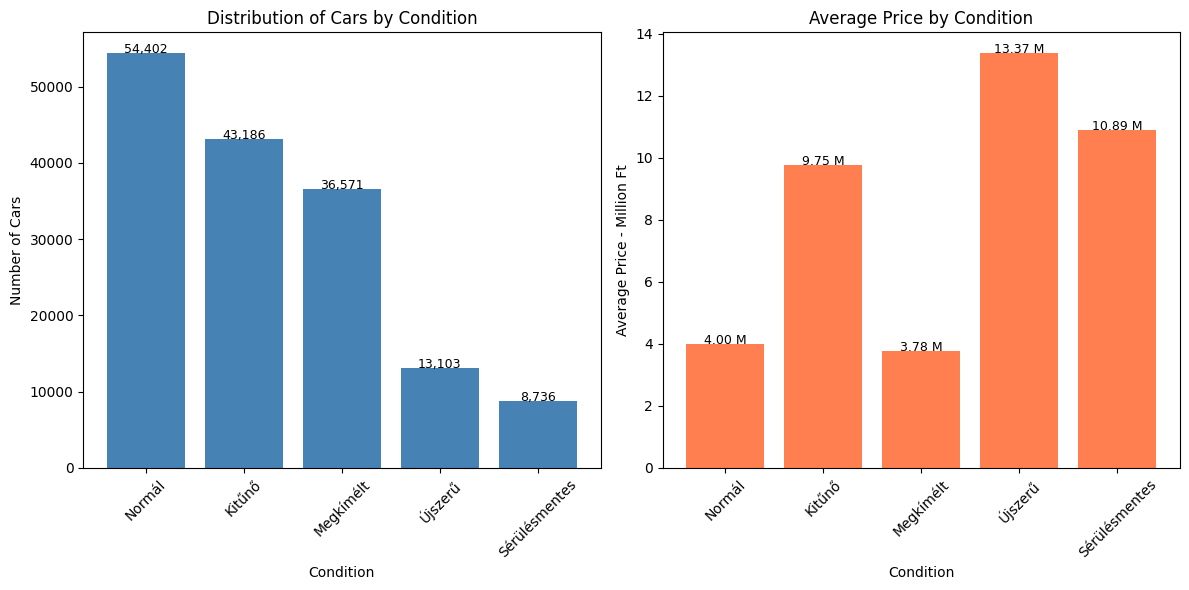

In [43]:
condition_counts = df['condition'].value_counts()
price_by_condition = df.groupby('condition')['price'].mean()

price_condition_df = pd.DataFrame({
    'Condition': condition_counts.index,
    'Count': condition_counts.values,
    'Avg Price - M': [price_by_condition[condition]/1e6 for condition in condition_counts.index]
})

display(price_condition_df.style.hide(axis='index'))


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(price_condition_df['Condition'], price_condition_df['Count'], color='steelblue')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars by Condition')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(price_condition_df['Condition'], price_condition_df['Avg Price - M'], color='coral')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Average Price by Condition')
axes[1].tick_params(axis='x', rotation=45)


for i, row in price_condition_df.iterrows():
    axes[0].text(i, row['Count'], f"{row['Count']:,}", ha='center', fontsize=9)
    axes[1].text(i, row['Avg Price - M'], f"{row['Avg Price - M']:.2f} M", ha='center', fontsize=9)



plt.tight_layout()
plt.show()

## **Body Type Analysis**

---

### **Unique Body Types & Their Average Prices**

Body Type,Count,Avg Price - M
Ferdehátú,44365,3.289462
Városi terepjáró (crossover),33202,10.843768
Kombi,28649,5.959967
Sedan,17379,6.817873
Egyterű,14940,2.963633
Coupe,5864,13.807041
Cabrio,3498,9.206667
Terepjáró,3145,14.291480
Kisbusz,2677,10.452733
Pickup,1010,10.934932


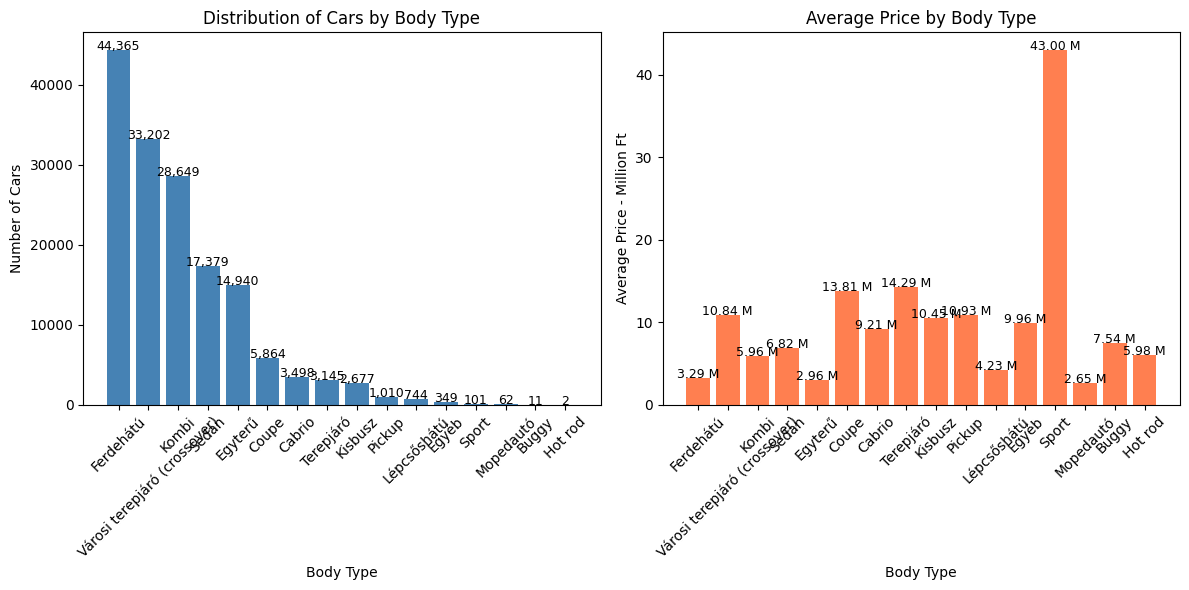

In [44]:
body_type_counts = df['body_type'].value_counts()
price_by_body_type = df.groupby('body_type')['price'].mean()

body_type_price_df = pd.DataFrame({
    'Body Type': body_type_counts.index,
    'Count': body_type_counts.values,
    'Avg Price - M': [price_by_body_type[body_type]/1e6 for body_type in body_type_counts.index]
})

display(body_type_price_df.style.hide(axis='index'))


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(body_type_price_df['Body Type'], body_type_price_df['Count'], color='steelblue')
axes[0].set_xlabel('Body Type')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars by Body Type')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(body_type_price_df['Body Type'], body_type_price_df['Avg Price - M'], color='coral')
axes[1].set_xlabel('Body Type')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Average Price by Body Type')
axes[1].tick_params(axis='x', rotation=45)


for i, row in body_type_price_df.iterrows():
    axes[0].text(i, row['Count'], f"{row['Count']:,}", ha='center', fontsize=9)
    axes[1].text(i, row['Avg Price - M'], f"{row['Avg Price - M']:.2f} M", ha='center', fontsize=9)



plt.tight_layout()
plt.show()

## **Engine Capacity Analysis**

---

### **Possible Data Errors with Electric Cars**

In [45]:
electric_count = (df['fuel_type'] == 'Elektromos').sum()

electric_mask = df['fuel_type'] == 'Elektromos'
electric_nan = df[electric_mask & df['engine_capacity'].isna()].shape[0]
electric_not_nan = df[electric_mask & df['engine_capacity'].notna()].shape[0]

electric_analysis_df = pd.DataFrame({
   'Category': ['Electric with NaN engine capacity', 'Electric with engine capacity value', 'Total Electric Cars'],
   'Count': [electric_nan, electric_not_nan, electric_count],
})

display(electric_analysis_df.style.hide(axis='index'))

Category,Count
Electric with NaN engine capacity,9197
Electric with engine capacity value,36
Total Electric Cars,9233


### **Ranges, & Their connection with price**

Range,Count,%,Avg Price - M
Electric,11688,7.49,11.830000
1 - 500,58,0.04,4.550000
500 - 1000,7039,4.51,3.790000
1000 - 1400,33420,21.42,3.380000
1400 - 1600,35558,22.79,4.760000
1600 - 1800,6971,4.47,3.570000
1800 - 2000,34309,21.99,7.030000
2000 - 2500,10115,6.48,6.250000
2500 - 3000,11445,7.34,13.350000
3000 - 4000,2889,1.85,24.230000


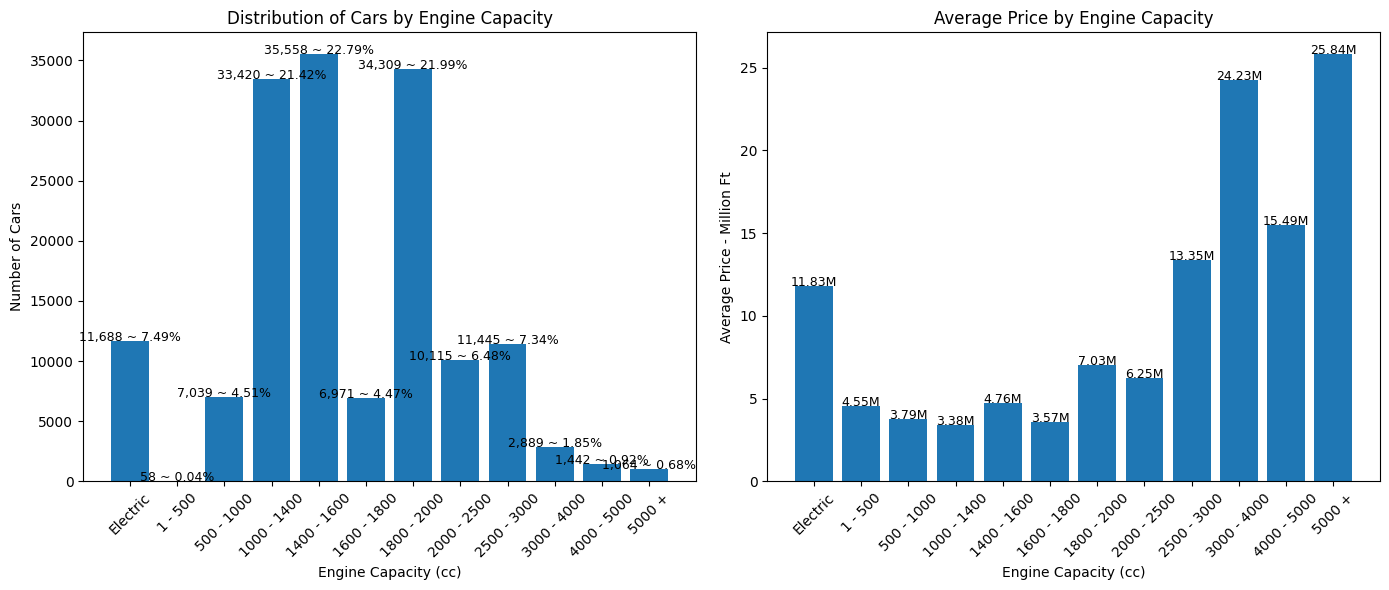

In [46]:
engine_ranges = [
   (0, 0, 'Electric'),
   (1, 500, '1 - 500'),
   (500, 1000, '500 - 1000'),
   (1000, 1400, '1000 - 1400'),
   (1400, 1600, '1400 - 1600'),
   (1600, 1800, '1600 - 1800'),
   (1800, 2000, '1800 - 2000'),
   (2000, 2500, '2000 - 2500'),
   (2500, 3000, '2500 - 3000'),
   (3000, 4000, '3000 - 4000'),
   (4000, 5000, '4000 - 5000'),
   (5000, float('inf'), '5000 +')
]

data = []
for low, high, label in engine_ranges:
   if low == 0 and high == 0:
      mask = df['engine_capacity'].isna() | (df['engine_capacity'] == 0)
   else:
      mask = (df['engine_capacity'] >= low) & (df['engine_capacity'] < high)
   
   count = mask.sum()
   percent = count / len(df) * 100
   
   subset = df[mask]
   avg_price = subset['price'].mean()
   
   data.append({
       'Range': label,
       'Count': count,
       '%': f'{percent:.2f}',
       'Avg Price - M': round(avg_price/1e6, 2)
   })

engine_ranges_df = pd.DataFrame(data)
display(engine_ranges_df.style.hide(axis='index'))


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(engine_ranges_df['Range'], engine_ranges_df['Count'])
axes[0].set_xlabel('Engine Capacity (cc)')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars by Engine Capacity')
axes[0].tick_params(axis='x', rotation=45)

for i, row in engine_ranges_df.iterrows():
   axes[0].text(i, row['Count'], f"{row['Count']:,} ~ {row['%']}%", 
        ha='center', fontsize=9)

axes[1].bar(engine_ranges_df['Range'], engine_ranges_df['Avg Price - M'])
axes[1].set_xlabel('Engine Capacity (cc)')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Average Price by Engine Capacity')
axes[1].tick_params(axis='x', rotation=45)

for i, row in engine_ranges_df.iterrows():
   axes[1].text(i, row['Avg Price - M'], f"{row['Avg Price - M']:.2f}M", 
        ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## **Drive Type Analysis**

---

### **Unique Values & Their Average Prices**

Drive Type,Count,Avg Price - M
Első kerék,105568,4.406346
Összkerék,28501,14.064634
Hátsó kerék,14977,8.664934
Kapcsolható összkerék,695,8.044620
Állandó összkerék,378,11.698885


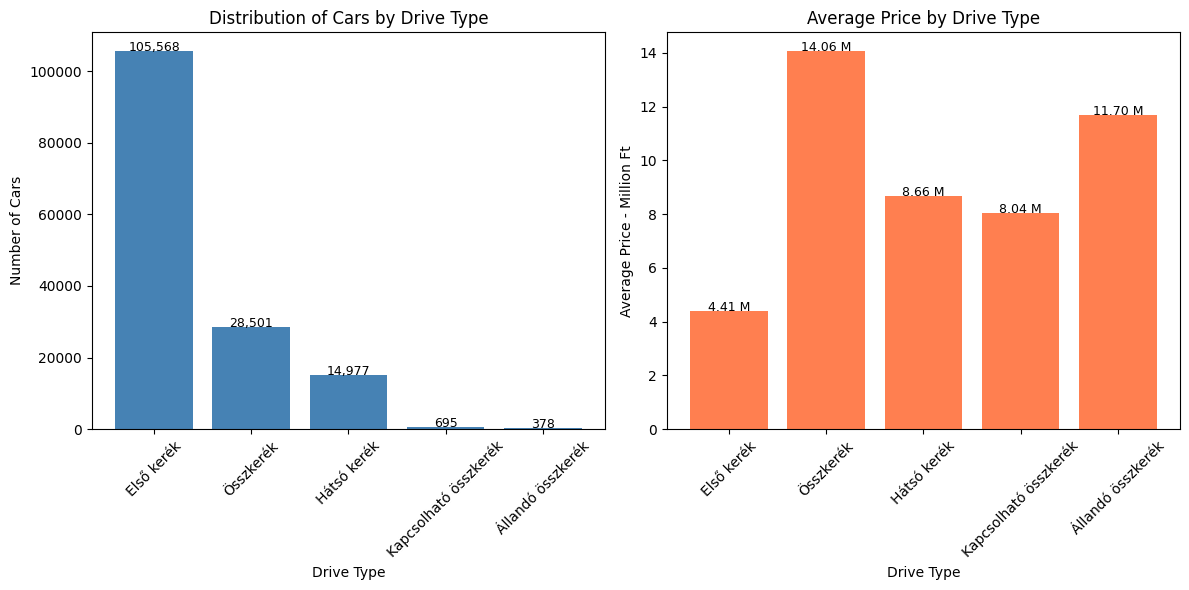

In [47]:
drive_type_counts = df['drive_type'].value_counts()
price_by_drive_type = df.groupby('drive_type')['price'].mean()

drive_type_price_df = pd.DataFrame({
   'Drive Type': drive_type_counts.index,
   'Count': drive_type_counts.values,
   'Avg Price - M': [price_by_drive_type[drive_type]/1e6 for drive_type in drive_type_counts.index]
})

display(drive_type_price_df.style.hide(axis='index'))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(drive_type_price_df['Drive Type'], drive_type_price_df['Count'], color='steelblue')
axes[0].set_xlabel('Drive Type')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars by Drive Type')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(drive_type_price_df['Drive Type'], drive_type_price_df['Avg Price - M'], color='coral')
axes[1].set_xlabel('Drive Type')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Average Price by Drive Type')
axes[1].tick_params(axis='x', rotation=45)

for i, row in drive_type_price_df.iterrows():
   axes[0].text(i, row['Count'], f"{row['Count']:,}", ha='center', fontsize=9)
   axes[1].text(i, row['Avg Price - M'], f"{row['Avg Price - M']:.2f} M", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## **Color Analysis**

---

### **Color Exploration**

Color,Count,Avg Price - M
Fehér,17222,6.605553
Fekete,13208,6.827957
Fekete (metál),12927,8.947023
Szürke (metál),7699,8.388829
Ezüst (metál),7400,5.162383
Szürke,6606,7.013593
Sötétszürke (metál),5258,7.484067
Fehér (metál),5013,11.193353
Ezüst,4465,4.084837
Kék (metál),3950,8.486109


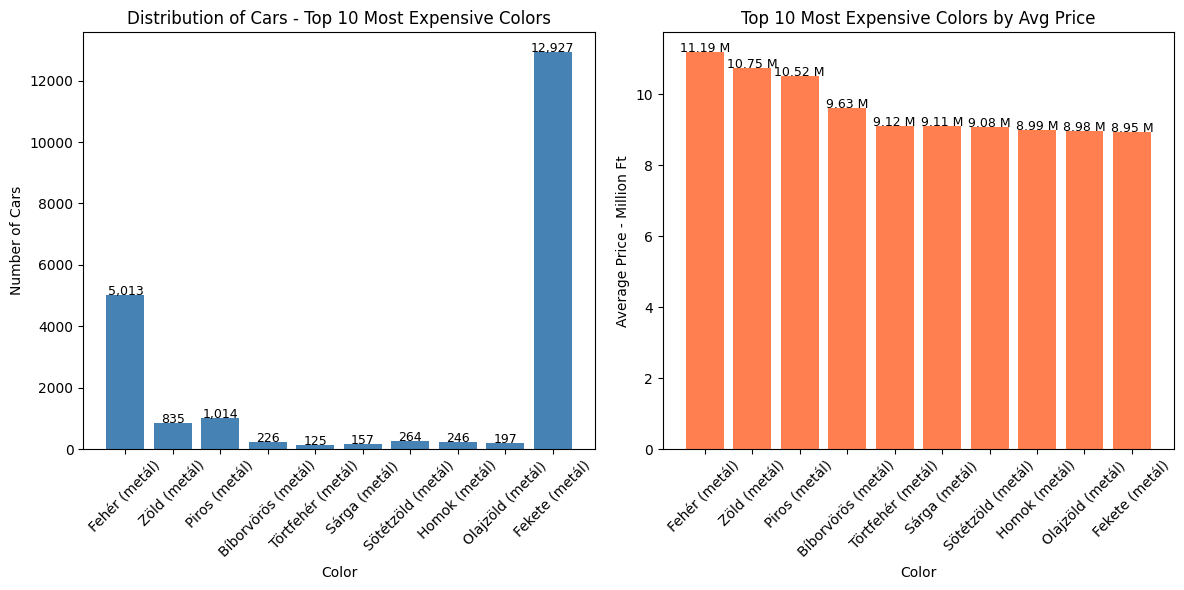

In [48]:
color_counts = df['color'].value_counts()
price_by_color = df.groupby('color')['price'].mean()

color_price_df = pd.DataFrame({
   'Color': color_counts.index,
   'Count': color_counts.values,
   'Avg Price - M': [price_by_color[color]/1e6 for color in color_counts.index]
})

display(color_price_df.style.hide(axis='index'))


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
filtered_colors = color_price_df[color_price_df['Count'] >= 100]
top_10_expensive = filtered_colors.nlargest(10, 'Avg Price - M')
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(top_10_expensive['Color'], top_10_expensive['Count'], color='steelblue')
axes[0].set_xlabel('Color')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars - Top 10 Most Expensive Colors')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(top_10_expensive['Color'], top_10_expensive['Avg Price - M'], color='coral')
axes[1].set_xlabel('Color')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Top 10 Most Expensive Colors by Avg Price')
axes[1].tick_params(axis='x', rotation=45)

for i, row in enumerate(top_10_expensive.itertuples()):
   axes[0].text(i, row.Count, f"{row.Count:,}", ha='center', fontsize=9)
   axes[1].text(i, getattr(row, '_3'), f"{getattr(row, '_3'):.2f} M", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


## **Transmission Types Analysis**

---

Transmission Type,Count,Avg Price - M
Manuális,89519,3.029211
Automata,43158,11.964692
Fokozatmentes automata,15164,11.958366
Szekvenciális,1091,4.142231
Tiptronic,64,28.825030
Automata felező váltóval,26,12.367863
Félautomata,25,1.624622
Manuális felező váltóval,8,2.725375
Fokozatmentes automata felező váltóval,6,5.006333


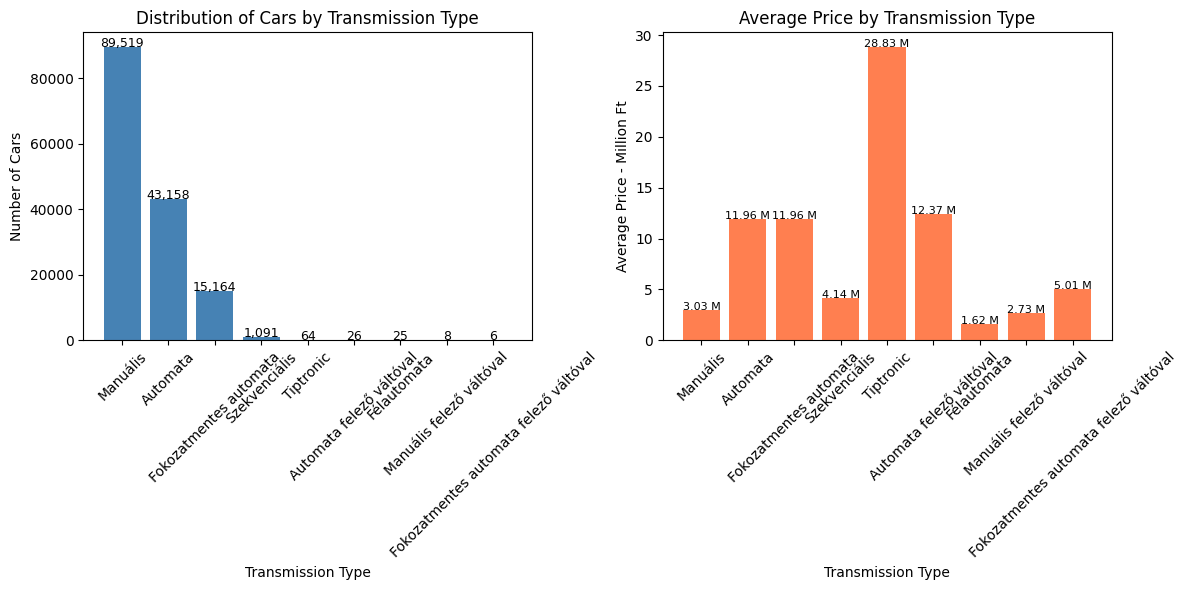

In [49]:
transmission_counts = df['transmission_type'].value_counts()
price_by_transmission = df.groupby('transmission_type')['price'].mean()

transmission_price_df = pd.DataFrame({
   'Transmission Type': transmission_counts.index,
   'Count': transmission_counts.values,
   'Avg Price - M': [price_by_transmission[transmission]/1e6 for transmission in transmission_counts.index]
})

display(transmission_price_df.style.hide(axis='index'))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(transmission_price_df['Transmission Type'], transmission_price_df['Count'], color='steelblue')
axes[0].set_xlabel('Transmission Type')
axes[0].set_ylabel('Number of Cars')
axes[0].set_title('Distribution of Cars by Transmission Type')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(transmission_price_df['Transmission Type'], transmission_price_df['Avg Price - M'], color='coral')
axes[1].set_xlabel('Transmission Type')
axes[1].set_ylabel('Average Price - Million Ft')
axes[1].set_title('Average Price by Transmission Type')
axes[1].tick_params(axis='x', rotation=45)

for i, row in transmission_price_df.iterrows():
   axes[0].text(i, row['Count'], f"{row['Count']:,}", ha='center', fontsize=9)
   axes[1].text(i, row['Avg Price - M'], f"{row['Avg Price - M']:.2f} M", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [50]:
transmission_subtypes = df['transmission_subtype'].value_counts()

transmission_subtypes_df = pd.DataFrame({
   'Transmission Subtype': transmission_subtypes.index,
   'Count': transmission_subtypes.values,
   '%': [f'{count/len(df)*100:.2f}' for count in transmission_subtypes.values]
})

display(transmission_subtypes_df.style.hide(axis='index'))

# ~~~~~~~~~~~~~~~~~~~~

tiptronic_cars = df[df['transmission_subtype'] == 'tiptronic']
transmission_types = tiptronic_cars['transmission_type'].value_counts()

tiptronic_df = pd.DataFrame({
    'Transmission Type': transmission_types.index,
    'Count': transmission_types.values,
    '%': [f'{count/len(tiptronic_cars)*100:.2f}' for count in transmission_types.values]
})

display(tiptronic_df.style.hide(axis='index'))

Transmission Subtype,Count,%
tiptronic,23690,15.19


Transmission Type,Count,%
Automata,23690,100.00
